In [1]:
import pickle as pkl
import numpy as np

In [128]:
def get_best_config(results, epsilon):
    best_config = {}
    best_result = np.inf
    for r in results:
        e = r["e"]
        if e != epsilon:
            continue
            
        lr = r["lr"]
        reg_factor = r["reg_factor"]
        valid_score = r["best_valid_sore"]
        n_epochs = len(r["train_scores_per_epoch"])
        test_mae = r["test_mae"]
        train_mae = r["train_scores_per_epoch"][-50]
        
        if valid_score < best_result:
            best_result = valid_score
            best_config = {"e": e, "lr": lr, "reg_factor": reg_factor, "n_epochs": n_epochs, "train_mae": train_mae.round(2), "valid_mae": valid_score.round(2), "test_mae": test_mae.round(2)}

    return best_config

In [133]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.hypertuning", "rb") as f:
    meta_results = pkl.load(f)
with open(PATH + "NoMetaMF.hypertuning", "rb") as f:
    nometa_results = pkl.load(f)
    
print("MetaMF")
metamf_best_configs = []
for e in [np.inf, 3, 2, 1, 0.1]:
    c = get_best_config(meta_results, epsilon=e)
    metamf_best_configs.append(c)
    print(c)
print()
print("NoMetaMF")
nometamf_best_configs = []
for e in [np.inf, 3, 2, 1, 0.1]:
    c = get_best_config(nometa_results, epsilon=e)
    nometamf_best_configs.append(c)
    print(c)

MetaMF
{'e': inf, 'lr': 0.0001, 'reg_factor': 0.001, 'n_epochs': 129, 'train_mae': 0.64, 'valid_mae': 0.68, 'test_mae': 0.69}
{'e': 3, 'lr': 1e-05, 'reg_factor': 0.001, 'n_epochs': 292, 'train_mae': 0.65, 'valid_mae': 0.69, 'test_mae': 0.69}
{'e': 2, 'lr': 1e-05, 'reg_factor': 0.001, 'n_epochs': 150, 'train_mae': 0.67, 'valid_mae': 0.7, 'test_mae': 0.7}
{'e': 1, 'lr': 0.0001, 'reg_factor': 0.001, 'n_epochs': 68, 'train_mae': 0.7, 'valid_mae': 0.72, 'test_mae': 0.72}
{'e': 0.1, 'lr': 0.0001, 'reg_factor': 0.001, 'n_epochs': 75, 'train_mae': 0.74, 'valid_mae': 0.76, 'test_mae': 0.76}

NoMetaMF
{'e': inf, 'lr': 0.001, 'reg_factor': 0.0001, 'n_epochs': 83, 'train_mae': 0.62, 'valid_mae': 0.7, 'test_mae': 0.7}
{'e': 3, 'lr': 0.001, 'reg_factor': 0.0001, 'n_epochs': 78, 'train_mae': 0.62, 'valid_mae': 0.71, 'test_mae': 0.71}
{'e': 2, 'lr': 0.001, 'reg_factor': 0.0001, 'n_epochs': 72, 'train_mae': 0.64, 'valid_mae': 0.72, 'test_mae': 0.72}
{'e': 1, 'lr': 0.0001, 'reg_factor': 0.001, 'n_epochs

In [134]:
with open(PATH + "MetaMF.best_params", "wb") as f:
    pkl.dump(metamf_best_configs, f)
with open(PATH + "NoMetaMF.best_params", "wb") as f:
    pkl.dump(nometamf_best_configs, f)

In [103]:
lrs = set()
reg_factors = set()
for r in meta_results:
    lrs.add(r["lr"])
    reg_factors.add(r["reg_factor"])
print(lrs)
print(reg_factors)

{1e-05, 0.0001, 0.001}
{0.0001, 0.01, 0.001}


In [104]:
res = [(r["e"], r["lr"], r["reg_factor"], r["best_valid_sore"], r["test_mae"]) for r in meta_results if r["e"] == np.inf]
sorted(res, key=lambda t: t[2])

[(inf, 1e-05, 0.0001, 1.3954801245623238, 1.399769061918442),
 (inf, 0.0001, 0.0001, 1.2632550718201385, 1.272037023977264),
 (inf, 0.001, 0.0001, 1.2712587451705566, 1.2737630173727705),
 (inf, 1e-05, 0.001, 1.4799382606869216, 1.4765950028876682),
 (inf, 0.0001, 0.001, 1.3156942650020778, 1.3103823438941777),
 (inf, 0.001, 0.001, 1.2604386598526776, 1.2625627026289374),
 (inf, 1e-05, 0.01, 1.554593485962231, 1.5549321263496365),
 (inf, 0.0001, 0.01, 1.1802712059856115, 1.180093979573512),
 (inf, 0.001, 0.01, 1.175956033546846, 1.1806471569197519)]

In [98]:
bsl = 1.18
errors = np.array([1.18, 0.73, 0.93, 1.51])
meta = (errors-bsl) / bsl

In [99]:
bsl = 1.36
errors = np.array([1.37, 0.84, 1.12, 2.04])
nometa = (errors-bsl) / bsl

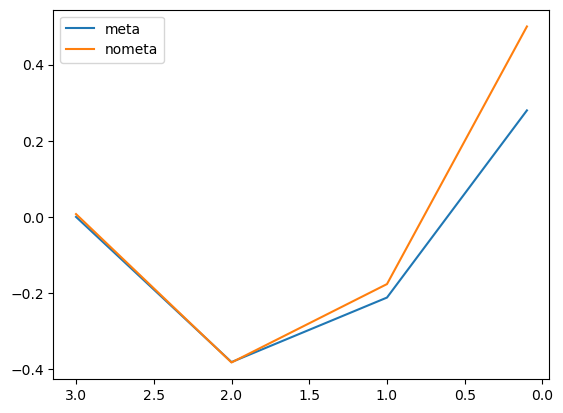

In [101]:
import matplotlib.pyplot as plt

betas = [3, 2, 1, 0.1]
plt.plot(betas, meta, label="meta")
plt.plot(betas, nometa, label="nometa")
plt.legend()
plt.gca().invert_xaxis()

In [107]:
meta - nometa

array([-0.00735294,  0.00099701, -0.03539382, -0.22033898])